# Reproducing `fire_los_recovery` — 2. The clean recovery arm

**Goal.** Re-derive the clean-recovery experiment — five training modes ×
n-grid × 3 trials on the FIRE truth — and validate it **row-by-row** against
the frozen `experiments/fire_los_recovery/results_vmap/results.csv` from
2026-07-29. With the same seeds and environment the reproduction is
**bit-exact** (verified for every n below).

**Checkpoints.** Training all ~75 models takes ~5–10 min on this machine.
Each n-group's trained weights are pickled under `checkpoints/clean_arm/`;
re-running the notebook loads them and skips straight to evaluation
(seconds). Delete that directory to retrain from scratch.

**Truth input.** By default this uses the frozen
`truth_old1gyr.npz` — but notebook 01 proved our rebuilt cache is bit-exact,
so pointing `TRUTH` at `cache/rebuild_*`-derived arrays would change
nothing.

In [37]:
import csv
import importlib.util
import pickle
import time
from pathlib import Path

import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import optax
from flax import nnx
import matplotlib.pyplot as plt

# the frozen run used the strictest matmul precision — keep it identical
jax.config.update('jax_default_matmul_precision', 'highest')

HERE = Path.cwd()                        # clean_experiments/fire_sims
REPO = HERE.parents[1]
EXP = REPO / 'experiments' / 'fire_los_recovery'
TRUTH = EXP / 'cache' / 'truth_old1gyr.npz'
CKPT_DIR = HERE / 'checkpoints' / 'clean_arm'
CKPT_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR = HERE / 'results_repro'
OUT_DIR.mkdir(exist_ok=True)

# load the experiment's dataset module under a unique name (its build_data
# is the verified scaling contract; we inspect rather than re-type it)
spec = importlib.util.spec_from_file_location('fire_datasets',
                                              EXP / 'datasets.py')
fd = importlib.util.module_from_spec(spec)
spec.loader.exec_module(fd)

from galactoPINNs.models.static_model import StaticModel
from galactoPINNs.train import train_model_static
from galactoPINNs.evaluate import (cylindrical_error_decomposition,
                                   error_decomposition)

print('jax backend:', jax.default_backend())

jax backend: cpu


## The data contract

`build_data` (in the experiment's `datasets.py`) turns the truth cache into
the exact 8-tuple the parent `sun_los_recovery` experiment used, plus the
FIRE extras:

- **Scaling is fit ONCE, on the 30k training pool**, via
  `galactoPINNs.data.scale_data` with `r_s = 15.62` kpc — kept from the
  parent so scaled quantities are directly comparable (for m12i this is a
  *non-dimensionalization choice*, not a fitted NFW radius).
- Every validation region is scaled **with the pool-fitted constant
  factors** — never refit on val data.
- The Sun anchor `(x_obs, a_obs)` and the smoothed-reference val labels come
  along scaled the same way.
- `sample_colloc_scaled` draws the ρ≥0 collocation points uniform-in-volume
  in a GC-centered 0.5–25 kpc shell (potential-agnostic — the prior is valid
  for any galaxy).

In [38]:
(x_pool, a_pool, x_pool_phys, cfg, val_scaled, dist_sun,
 x_obs, a_obs, val_sm, meta) = fd.build_data(TRUTH, n_val=4096)

print(f'pool: {x_pool.shape}, scaled |x| max = '
      f'{float(jnp.linalg.norm(x_pool, axis=1).max()):.3f}')
print(f'|a_frame|/|a_obs| = '
      f"{meta['checks']['frame']['a_frame_over_a_obs']:.3f}")
for name, (xv, av) in val_scaled.items():
    gap = float(jnp.median(jnp.linalg.norm(av - val_sm[name], axis=1)
                           / jnp.linalg.norm(av, axis=1)))
    print(f'val {name:6s}: {xv.shape[0]} pts, '
          f'median |a_true - a_sm|/|a| = {gap:.3f}')

pool: (30000, 3), scaled |x| max = 0.773
|a_frame|/|a_obs| = 0.046
val sun4  : 4096 pts, median |a_true - a_sm|/|a| = 0.019
val sun15 : 4096 pts, median |a_true - a_sm|/|a| = 0.056
val gc15  : 4096 pts, median |a_true - a_sm|/|a| = 0.057


## The five training modes, as one vmapped batch

The heart of the driver. Each model's loss is a weighted switch
`w = (w_3d, w_los, anchor_on, λ_anchor, λ_rho)` over three ingredients:

- **3D loss** — full vectors: `|Δa| + |Δa|/|a|` (absolute + relative), the
  paper's loss.
- **LOS loss** — pulsar-like: `|(a_pred − a_true)·n̂|` per star, with the
  optional **Sun anchor** folded into the *same mean* (the earlier
  mean-of-means bug is exactly what this denominator avoids).
- **ρ≥0 penalty** — `relu(−∇²Φ)` averaged over the collocation points;
  active only in the `+rho` modes.

Because the switch weights are *data*, a single `vmap` +`lax.scan` trains
heterogeneous modes simultaneously; models needing the Laplacian live in a
second group so the others never pay for it. `stack_states` stacks the
per-model parameter pytrees into one batched pytree.

In [39]:
MODES = ('3D', 'LOS', 'LOS+Sun', 'LOS+rho', 'LOS+Sun+rho')
NORHO_MODES = ('3D', 'LOS', 'LOS+Sun')
RHO_MODES = ('LOS+rho', 'LOS+Sun+rho')
REGIONS = ('sun4', 'sun15', 'gc15')
LAMBDA_REL, EPS = 1.0, 1e-10


def mode_weight_row(mode, lambda_sun, lambda_rho):
    return {'3D':          (1.0, 0.0, 0.0, 0.0, 0.0),
            'LOS':         (0.0, 1.0, 0.0, 0.0, 0.0),
            'LOS+Sun':     (0.0, 1.0, 1.0, lambda_sun, 0.0),
            'LOS+rho':     (0.0, 1.0, 0.0, 0.0, lambda_rho),
            'LOS+Sun+rho': (0.0, 1.0, 1.0, lambda_sun, lambda_rho)}[mode]


def make_ensemble_fns(graphdef, rest, x_obs, a_obs, tx, epochs):
    def data_terms(m, x, a, nv, w):
        w3d, wlos, anch_on, lam_anchor, _ = w
        a_pred = m(x)['acceleration']
        diff_norm = jnp.linalg.norm(a_pred - a, axis=1)
        true_norm = jnp.linalg.norm(a, axis=1)
        loss3d = jnp.mean(diff_norm + LAMBDA_REL * diff_norm / (true_norm + EPS))
        alos_pred = jnp.sum(a_pred * nv, axis=1)
        alos_true = jnp.sum(a * nv, axis=1)
        perlos = jnp.abs(alos_pred - alos_true)
        anchor_abs = jnp.abs(m(x_obs)['acceleration'] - a_obs).reshape(-1)
        denom = x.shape[0] + anch_on * anchor_abs.size
        loss_los = (jnp.sum(perlos)
                    + anch_on * lam_anchor * jnp.sum(anchor_abs)) / denom
        return w3d * loss3d + wlos * loss_los

    def loss_norho(params, x, a, nv, w):
        m = nnx.merge(graphdef, params, rest)
        return data_terms(m, x, a, nv, w)

    def loss_rho(params, x, a, nv, colloc, w):
        m = nnx.merge(graphdef, params, rest)
        lap = m.compute_laplacian(colloc)
        return data_terms(m, x, a, nv, w) + w[4] * jnp.mean(jax.nn.relu(-lap))

    def make_trainer(loss_fn):
        @jax.jit
        def train_group(params, opt, *arrays):
            def stepf(carry, _):
                p, o = carry
                losses, grads = jax.vmap(jax.value_and_grad(loss_fn))(p, *arrays)
                updates, o = tx.update(grads, o, p)
                return (optax.apply_updates(p, updates), o), losses
            (p, _), hist = jax.lax.scan(stepf, (params, opt), None,
                                        length=epochs)
            return p, hist[-1]
        return train_group

    @jax.jit
    def eval_group(params, x_val, x_lap):
        def one(p, xv, xl):
            m = nnx.merge(graphdef, p, rest)
            return (m(xv)['acceleration'],
                    jnp.mean(m.compute_laplacian(xl) < 0.0))
        return jax.vmap(one, in_axes=(0, None, None))(params, x_val, x_lap)

    return make_trainer(loss_norho), make_trainer(loss_rho), eval_group


def stack_states(states):
    return jax.tree.map(lambda *xs: jnp.stack(xs), *states)


def take_member(stacked, i):
    return jax.tree.map(lambda x: x[i], stacked)


def train_one_n(x_by_trial, a_by_trial, nv_by_trial, colloc_by_trial,
                params_by_trial, trainers, tx, lambda_sun=1.0, lambda_rho=1.0):
    train_norho, train_rho = trainers
    trials = len(x_by_trial)
    out = {}
    for modes, needs_rho, trainer in ((NORHO_MODES, False, train_norho),
                                      (RHO_MODES, True, train_rho)):
        specs = [(t, mode) for t in range(trials) for mode in modes]
        X = jnp.stack([x_by_trial[t] for t, _ in specs])
        A = jnp.stack([a_by_trial[t] for t, _ in specs])
        NV = jnp.stack([nv_by_trial[t] for t, _ in specs])
        W = jnp.asarray([mode_weight_row(m, lambda_sun, lambda_rho)
                         for _, m in specs], dtype=jnp.float32)
        params = stack_states([params_by_trial[t] for t, _ in specs])
        opt = tx.init(params)
        arrays = (X, A, NV) if not needs_rho else (
            X, A, NV, jnp.stack([colloc_by_trial[t] for t, _ in specs]))
        t0 = time.time()
        trained, final_loss = trainer(params, opt, *arrays, W)
        jax.block_until_ready(trained)
        print(f"    {len(specs)} models [{'+'.join(modes)}] "
              f'in {time.time()-t0:.1f}s', flush=True)
        for i, spec_ in enumerate(specs):
            out[spec_] = (trained, i, float(final_loss[i]))
    return out

## Self-test: the vmapped ensemble must equal the sequential trainer

Same contract as the driver's `--self-test`: train a tiny problem (n=40,
30 epochs) both ways — our batched trainer vs the library's
`train_model_static` (the code path of the original paper) — and demand
parameter agreement. The frozen run recorded reldiffs ~5×10⁻⁸; we should
see the same.

In [40]:
n_st, epochs_st, lam = 40, 30, 1.0
idx = np.random.default_rng(0).choice(x_pool.shape[0], n_st, replace=False)
x_n, a_n = x_pool[idx], a_pool[idx]
dx = x_pool_phys[idx] - fd.OBSERVER
nv_st = jnp.asarray(dx / np.linalg.norm(dx, axis=1, keepdims=True))
colloc_st = fd.sample_colloc_scaled(jr.PRNGKey(1000), 64, 0.5, 25.0,
                                    cfg['x_transformer'])

template = StaticModel(cfg, rngs=nnx.Rngs(0))
graphdef, params0, rest = nnx.split(template, nnx.Param, ...)
tx = optax.adam(1e-3)
trainers_st = make_ensemble_fns(graphdef, rest, x_obs, a_obs, tx,
                                epochs_st)[:2]
res_st = train_one_n([x_n], [a_n], [nv_st], [colloc_st], [params0],
                     trainers_st, tx, lam, lam)

seq_kwargs = {
    '3D': dict(),
    'LOS': dict(n_vecs=nv_st, line_of_sight=True),
    'LOS+Sun': dict(n_vecs=nv_st, line_of_sight=True,
                    anchor_x=x_obs, anchor_a=a_obs, lambda_anchor=lam),
    'LOS+rho': dict(n_vecs=nv_st, line_of_sight=True, colloc_x=colloc_st,
                    lambda_rho=lam),
    'LOS+Sun+rho': dict(n_vecs=nv_st, line_of_sight=True, anchor_x=x_obs,
                        anchor_a=a_obs, lambda_anchor=lam,
                        colloc_x=colloc_st, lambda_rho=lam),
}
for mode in MODES:
    model = StaticModel(cfg, rngs=nnx.Rngs(0))
    train_model_static(model, optax.adam(1e-3), x_n, a_n, epochs_st,
                       log_every=0, **seq_kwargs[mode])
    _, p_seq, _ = nnx.split(model, nnx.Param, ...)
    stacked, i, _ = res_st[(0, mode)]
    p_vmap = take_member(stacked, i)
    num = sum(float(jnp.sum((a - b) ** 2)) for a, b in
              zip(jax.tree.leaves(p_seq), jax.tree.leaves(p_vmap)))
    den = sum(float(jnp.sum(a ** 2)) for a in jax.tree.leaves(p_seq))
    rel = (num / den) ** 0.5
    assert rel < 1e-4, f'{mode}: reldiff {rel:.2e}'
    print(f'{mode:12s} param reldiff vs sequential: {rel:.2e}  ok')
print('self-test PASSED')

    3 models [3D+LOS+LOS+Sun] in 0.9s
    2 models [LOS+rho+LOS+Sun+rho] in 1.5s
3D           param reldiff vs sequential: 5.41e-08  ok
LOS          param reldiff vs sequential: 4.23e-08  ok
LOS+Sun      param reldiff vs sequential: 4.70e-08  ok
LOS+rho      param reldiff vs sequential: 4.56e-08  ok
LOS+Sun+rho  param reldiff vs sequential: 5.41e-08  ok
self-test PASSED


## The sweep, with checkpoints

Seeding protocol (identical to the frozen run — this is what makes the
comparison bit-exact):

- trial t's **n-subset** of the pool: `np.random.default_rng(t)`;
- trial t's **initial weights**: `nnx.Rngs(t)`;
- trial t's **collocation points**: `jr.PRNGKey(1000 + t)`;
- optimizer `adam(1e-3)`, 1500 epochs, λ_sun = λ_rho = 1.

Each n-group (15 models) is trained once and pickled — the stacked
parameter pytree cast to numpy, exactly the `noisy_data_arch` bundle
pattern. Re-runs load the pickle and only re-evaluate.

In [41]:
N_GRID = [50, 100, 200, 500, 1000]
TRIALS, EPOCHS = 3, 1500

params_by_trial = [nnx.split(StaticModel(cfg, rngs=nnx.Rngs(t)),
                             nnx.Param, ...)[1] for t in range(TRIALS)]
colloc_by_trial = [fd.sample_colloc_scaled(jr.PRNGKey(1000 + t), 512, 0.5,
                                           25.0, cfg['x_transformer'])
                   for t in range(TRIALS)]
train_norho, train_rho, eval_group = make_ensemble_fns(
    graphdef, rest, x_obs, a_obs, tx, EPOCHS)

trained_groups = {}          # n -> list of {'state': ..., 'members': ...}
for n in N_GRID:
    f = CKPT_DIR / f'n{n}.pkl'
    if f.exists():
        with open(f, 'rb') as fh:
            trained_groups[n] = pickle.load(fh)
        print(f'n={n}: loaded checkpoint ({f.name})')
        continue
    print(f'n={n}: training...')
    x_bt, a_bt, nv_bt = [], [], []
    for trial in range(TRIALS):
        rng = np.random.default_rng(trial)
        sel = rng.choice(x_pool.shape[0], size=n, replace=False)
        x_bt.append(x_pool[sel]); a_bt.append(a_pool[sel])
        dxq = x_pool_phys[sel] - fd.OBSERVER
        nv_bt.append(jnp.asarray(
            dxq / np.linalg.norm(dxq, axis=1, keepdims=True)))
    results = train_one_n(x_bt, a_bt, nv_bt, colloc_by_trial,
                          params_by_trial, (train_norho, train_rho), tx)
    group_ids = {}
    for spec_, (stacked, i, _) in results.items():
        group_ids.setdefault(id(stacked), (stacked, []))[1].append((spec_, i))
    bundle = [{'state': jax.tree.map(np.asarray, stacked), 'members': members}
              for stacked, members in group_ids.values()]
    with open(f, 'wb') as fh:
        pickle.dump(bundle, fh)
    trained_groups[n] = bundle
    print(f'n={n}: checkpointed -> {f.name}')

n=50: loaded checkpoint (n50.pkl)
n=100: loaded checkpoint (n100.pkl)
n=200: loaded checkpoint (n200.pkl)
n=500: loaded checkpoint (n500.pkl)
n=1000: loaded checkpoint (n1000.pkl)


## Evaluation

For every (n, trial, mode, region): predict on the 4096 val points, then

- `rel_err` — mean |Δa|/|a| against the **true clumpy field**;
- `rel_err_sm` — the same against the **0.5 kpc smoothed reference**
  (the gap to `rel_err` is the graininess floor);
- `neg_frac` — fraction of val points where the model's ∇²Φ < 0 (unphysical
  negative density);
- LOS/transverse and cylindrical (R, z, φ) decompositions.

In [42]:
x_tf = cfg['x_transformer']
val_geom = {}
for name in REGIONS:
    x_val, a_val = val_scaled[name]
    xv_phys = np.asarray(x_tf.inverse_transform(x_val))
    dxv = xv_phys - fd.OBSERVER
    val_geom[name] = (xv_phys,
                      jnp.asarray(dxv / np.linalg.norm(dxv, axis=1,
                                                       keepdims=True)))

rows = []
t0 = time.time()
for n in N_GRID:
    for g in trained_groups[n]:
        stacked = jax.tree.map(jnp.asarray, g['state'])
        for region in REGIONS:
            x_val, a_val = val_scaled[region]
            apred, neg = eval_group(stacked, x_val, x_val[:512])
            xv_phys, nhat = val_geom[region]
            for (trial, mode), i in g['members']:
                d = error_decomposition(a_val, apred[i], nhat)
                dsm = error_decomposition(val_sm[region], apred[i], nhat)
                c = cylindrical_error_decomposition(a_val, apred[i],
                                                    jnp.asarray(xv_phys))
                rows.append(dict(
                    n_samples=n, trial=trial, mode=mode, region=region,
                    rel_err=float(jnp.mean(d['rel_error_magnitude'])),
                    neg_frac=float(neg[i]),
                    rel_los=float(jnp.mean(d['rel_los_error'])),
                    rel_trv=float(jnp.mean(d['rel_transverse_error'])),
                    rel_R=float(jnp.mean(c['rel_R_error'])),
                    rel_z=float(jnp.mean(c['rel_z_error'])),
                    rel_phi=float(jnp.mean(c['rel_phi_error'])),
                    rel_err_sm=float(jnp.mean(dsm['rel_error_magnitude'])),
                    rel_los_sm=float(jnp.mean(dsm['rel_los_error'])),
                    rel_trv_sm=float(jnp.mean(dsm['rel_transverse_error']))))
print(f'evaluated {len(rows)} rows in {time.time()-t0:.0f} s')

with open(OUT_DIR / 'results.csv', 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    w.writeheader(); w.writerows(rows)
print('wrote', OUT_DIR / 'results.csv')

evaluated 225 rows in 3 s
wrote /Users/pablom.perez/Desktop/Linas-group/galactoPINNs/clean_experiments/fire_sims/results_repro/results.csv


## Row-by-row validation against the frozen results

Every metric of every (n, trial, mode, region) row is compared with the
2026-07-29 `results_vmap/results.csv`. Expectation: **bit-exact** (same
seeds, same env, same matmul precision) — the assert below tolerates only
float-printing noise.

In [43]:
frozen_rows = {}
with open(EXP / 'results_vmap' / 'results.csv') as f:
    for r in csv.DictReader(f):
        key = (int(r['n_samples']), int(r['trial']), r['mode'], r['region'])
        frozen_rows[key] = {k: float(v) for k, v in r.items()
                            if k not in ('n_samples', 'trial', 'mode',
                                         'region')}

worst, worst_key = 0.0, None
per_n = {}
for row in rows:
    key = (row['n_samples'], row['trial'], row['mode'], row['region'])
    fz = frozen_rows[key]
    d = max(abs(row[k] - fz[k]) for k in fz)
    per_n[key[0]] = max(per_n.get(key[0], 0.0), d)
    if d > worst:
        worst, worst_key = d, key
for n in N_GRID:
    print(f'n={n:5d}: worst |delta| across all rows/metrics = '
          f'{per_n[n]:.3e}')
where = f' (at {worst_key})' if worst > 0 else ' — bit-exact'
print(f'overall worst: {worst:.3e}{where}')
assert worst < 1e-6, 'reproduction drifted from the frozen results!'
print(f'all {len(rows)} rows match the frozen results.csv ✓')

n=   50: worst |delta| across all rows/metrics = 0.000e+00
n=  100: worst |delta| across all rows/metrics = 0.000e+00
n=  200: worst |delta| across all rows/metrics = 0.000e+00
n=  500: worst |delta| across all rows/metrics = 0.000e+00
n= 1000: worst |delta| across all rows/metrics = 0.000e+00
overall worst: 0.000e+00 — bit-exact
all 225 rows match the frozen results.csv ✓


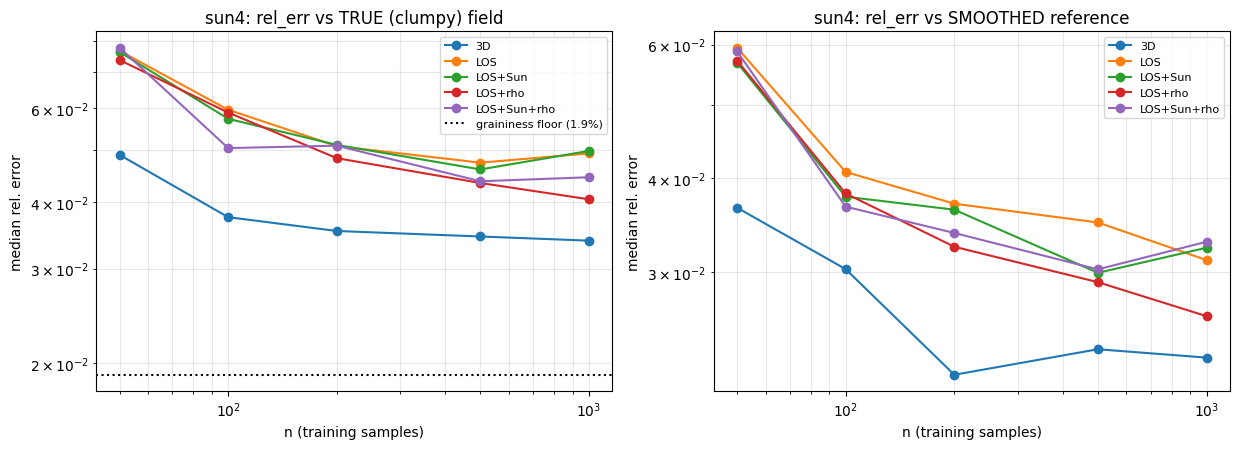

In [44]:
import collections

med = collections.defaultdict(dict)   # (region, mode) -> {n: median rel_err}
med_sm = collections.defaultdict(dict)
for row in rows:
    med[(row['region'], row['mode'])].setdefault(row['n_samples'], []).append(
        row['rel_err'])
    med_sm[(row['region'], row['mode'])].setdefault(
        row['n_samples'], []).append(row['rel_err_sm'])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
colors = dict(zip(MODES, [f'C{i}' for i in range(5)]))
for ax, table, title in [
        (axes[0], med, 'sun4: rel_err vs TRUE (clumpy) field'),
        (axes[1], med_sm, 'sun4: rel_err vs SMOOTHED reference')]:
    for mode in MODES:
        vals = table[('sun4', mode)]
        ns = sorted(vals)
        ax.plot(ns, [np.median(vals[n]) for n in ns], 'o-',
                color=colors[mode], label=mode)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('n (training samples)'); ax.set_ylabel('median rel. error')
    ax.set_title(title)
    ax.grid(alpha=0.3, which='both')
axes[0].axhline(0.019, color='k', ls=':', lw=1.5,
                label='graininess floor (1.9%)')
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)
fig.tight_layout()

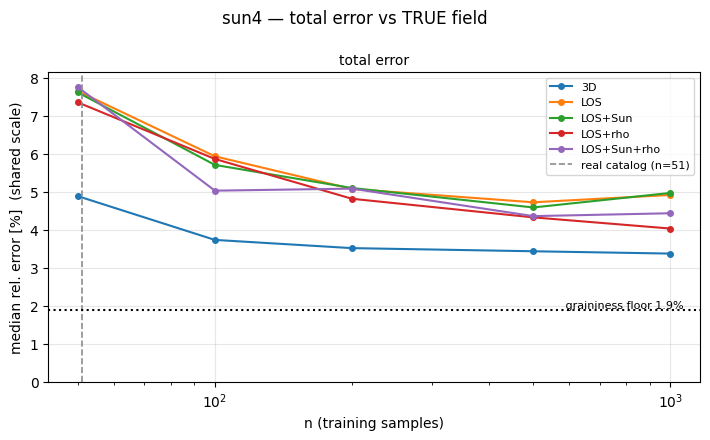

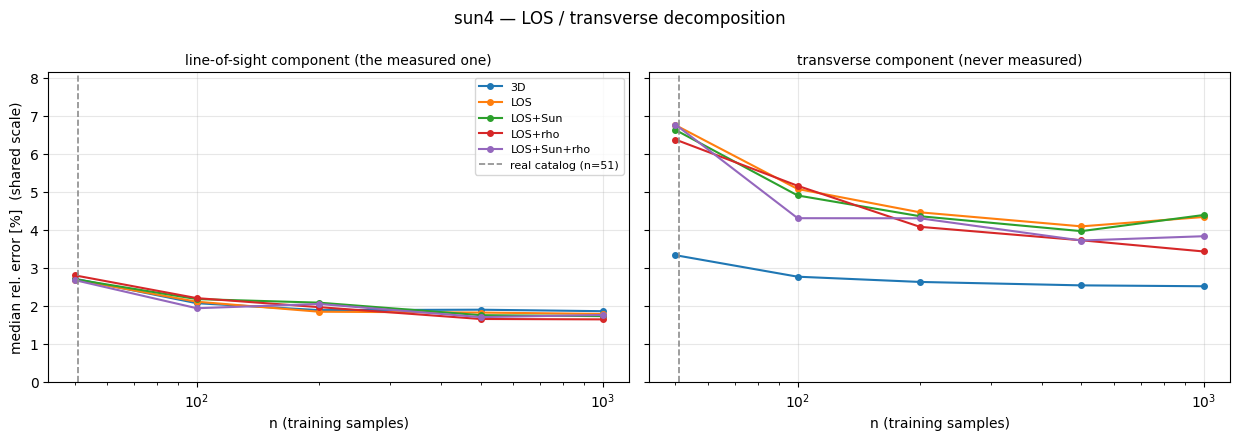

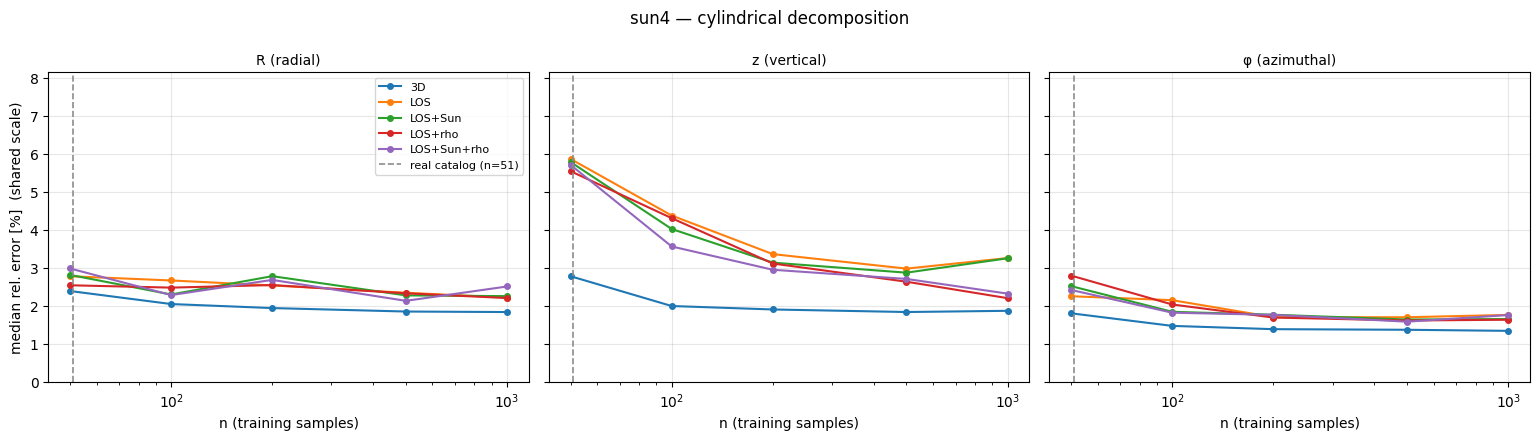

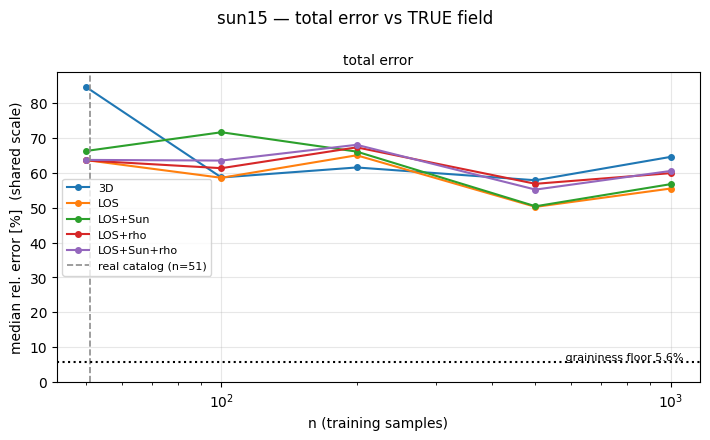

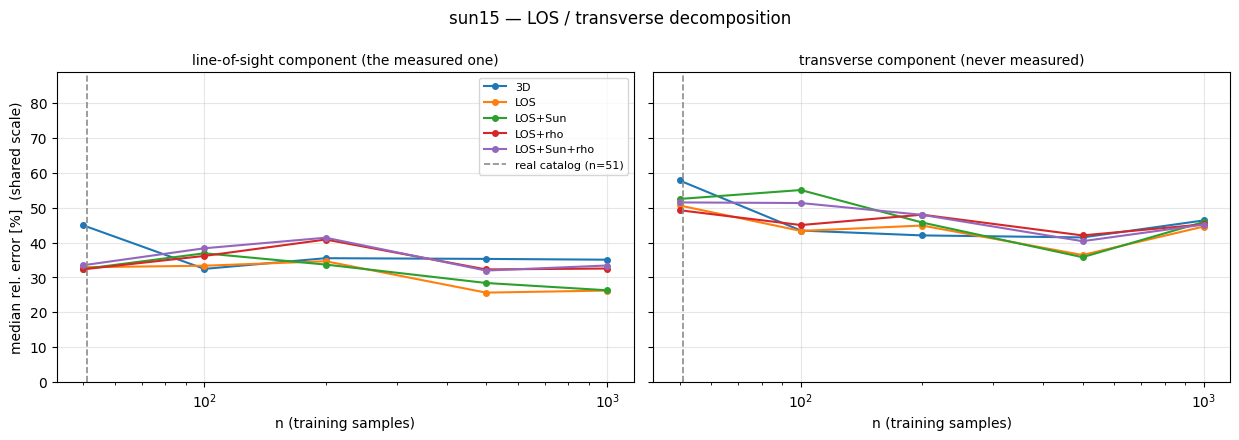

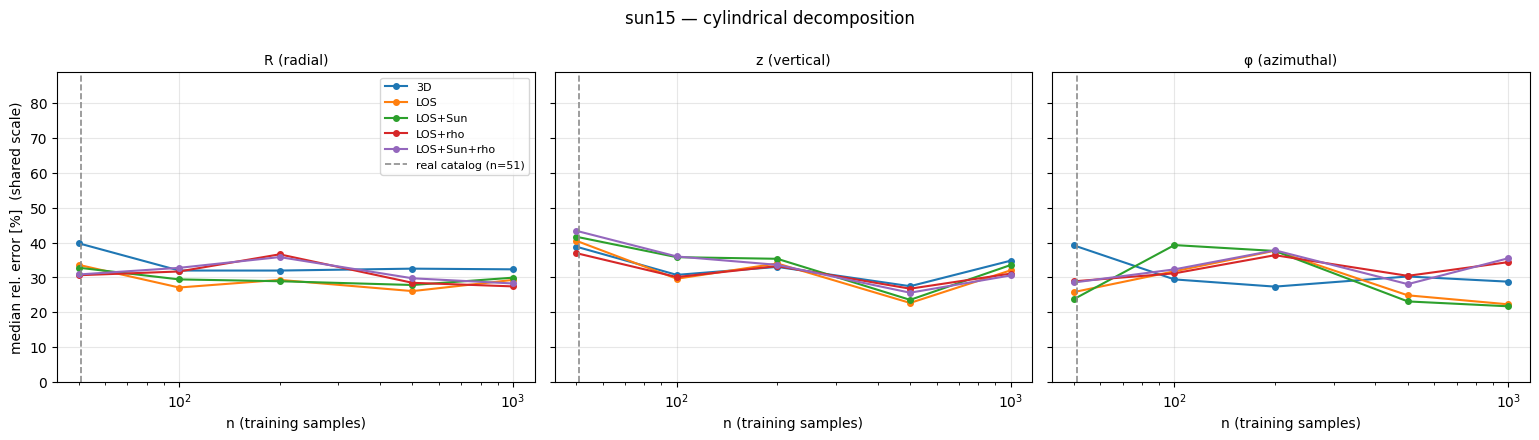

In [45]:
import collections

# median-over-trials curves: (region, mode) -> {n: [trial values]}
def collect(metric):
    out = collections.defaultdict(dict)
    for row in rows:
        out[(row['region'], row['mode'])].setdefault(
            row['n_samples'], []).append(row[metric])
    return out


def median_curve(table, region, mode):
    vals = table[(region, mode)]
    ns = sorted(vals)
    return ns, [100.0 * np.median(vals[n]) for n in ns]   # percent


colors = dict(zip(MODES, [f'C{i}' for i in range(5)]))
N_CATALOG = 51                                # the real Donlon+2025 count
ALL_METRICS = ('rel_err', 'rel_los', 'rel_trv', 'rel_R', 'rel_z', 'rel_phi')
TABLES = {m: collect(m) for m in ALL_METRICS}


def region_ymax(region):
    """One shared y-limit for a region's whole suite: the largest median
    curve of ANY metric/mode (in practice the vertical-z component)."""
    return 1.05 * max(max(median_curve(TABLES[m], region, mode)[1])
                      for m in ALL_METRICS for mode in MODES)


def floor_pct(region):
    """Graininess floor from the data (median |a_true - a_sm|/|a_true|):
    the fraction of the local field that is sub-0.5-kpc texture — the level
    below which NO smooth model can score against the clumpy truth."""
    av = val_scaled[region][1]
    return 100.0 * float(jnp.median(
        jnp.linalg.norm(av - val_sm[region], axis=1)
        / jnp.linalg.norm(av, axis=1)))


def _panel(ax, table, region, ymax, title, label_lines=False):
    for mode in MODES:
        ns, ys = median_curve(table, region, mode)
        ax.plot(ns, ys, 'o-', color=colors[mode], ms=4, label=mode)
    ax.axvline(N_CATALOG, color='0.55', ls='--', lw=1.2,
               label='real catalog (n=51)' if label_lines else None)
    ax.set_xscale('log')
    ax.set_ylim(0, ymax)
    ax.set_xlabel('n (training samples)')
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.3)


def _floor_line(ax, fl):
    ax.axhline(fl, color='k', ls=':', lw=1.5)
    ax.text(0.98, fl, f' graininess floor {fl:.1f}% ', fontsize=8,
            ha='right', va='bottom', transform=ax.get_yaxis_transform())


def suite(region):
    """Figures on ONE shared y-scale, so any panel compares to any other —
    the scale is set by the worst component (the vertical z). All errors
    are vs the TRUE clumpy field; the dotted line marks the graininess
    floor, i.e. how much of the remaining error is irreducible texture."""
    ymax = region_ymax(region)
    fl = floor_pct(region)

    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    _panel(ax, TABLES['rel_err'], region, ymax, 'total error',
           label_lines=True)
    _floor_line(ax, fl)
    ax.set_ylabel('median rel. error [%]  (shared scale)')
    ax.legend(fontsize=8)
    fig.suptitle(f'{region} — total error vs TRUE field', y=0.99)
    fig.tight_layout()

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4), sharey=True)
    _panel(axes[0], TABLES['rel_los'], region, ymax,
           'line-of-sight component (the measured one)', label_lines=True)
    _panel(axes[1], TABLES['rel_trv'], region, ymax,
           'transverse component (never measured)')
    axes[0].set_ylabel('median rel. error [%]  (shared scale)')
    axes[0].legend(fontsize=8)
    fig.suptitle(f'{region} — LOS / transverse decomposition', y=0.99)
    fig.tight_layout()

    fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4), sharey=True)
    for ax, key, label in [(axes[0], 'rel_R', 'R (radial)'),
                           (axes[1], 'rel_z', 'z (vertical)'),
                           (axes[2], 'rel_phi', 'φ (azimuthal)')]:
        _panel(ax, TABLES[key], region, ymax, label,
               label_lines=(key == 'rel_R'))
    axes[0].set_ylabel('median rel. error [%]  (shared scale)')
    axes[0].legend(fontsize=8)
    fig.suptitle(f'{region} — cylindrical decomposition', y=0.99)
    fig.tight_layout()


suite('sun4')
suite('sun15')
plt.show()

## Wrap-up

Proven here, on top of notebook 01's bit-exact truth:

- the vmapped five-mode ensemble equals the sequential paper trainer
  (reldiff ~5×10⁻⁸);
- the full clean arm (75 models) reproduces the frozen
  `results_vmap/results.csv` row-by-row;
- checkpointed weights under `checkpoints/clean_arm/` make re-runs
  evaluation-only.

The remaining July-29 arms reproduce the same way when you want them:
**noise** (`noise.py` + Donlon+25 σ's), **architecture ladder**
(`run_arch_vmap.py`), and the **ρ_DM,☉ extraction** (`density.py` — the
Discord table). Each can be a third notebook following this template.

## Appendix — learning curves at n=50: train loss and validation error per epoch

The sweep's trainer runs inside `lax.scan` and keeps only the final state,
so here we build a *tracking* variant: same losses, same optimizer, but the
scan also records each model's training loss and its validation error
(mean |Δa|/|a| on a 512-point sun4 subset) at **every epoch**. Trial 0,
n=50, all five modes, ~25 s.

What to look for (and what the run below shows):

- Almost all the fitting happens in the first ~100 epochs; after that it's
  a slow, noisy grind. The jitter is real — full-batch Adam on nonsmooth
  L1-type losses, not minibatch noise.
- **No overfitting at n=50**: the validation curves are still flat-to-
  improving at epoch 1500 (minima land around epochs 1100–1500), so the
  fixed 1500-epoch budget is justified — early stopping would buy little.
- 3D separates from the LOS family by ~epoch 200 and converges to its
  ~4% ceiling; the four LOS-based modes cluster around 7–8% at this n.
- Caveat: train-loss **levels** are not comparable across modes — 3D's
  loss includes a relative term while LOS losses are absolute-only, so
  they live in different units. Compare shapes, not heights. The honest
  cross-mode comparison is the right panel (same metric for all).

tracked 3 models [3D+LOS+LOS+Sun] in 5.5s
tracked 2 models [LOS+rho+LOS+Sun+rho] in 20.8s

final epoch (train loss | val rel_err on the sun4 subset):
  3D           0.0428 | 0.0396   (val min 0.0357 at epoch 1127)
  LOS          0.0109 | 0.0776   (val min 0.0694 at epoch 1399)
  LOS+Sun      0.0090 | 0.0705   (val min 0.0659 at epoch 1491)
  LOS+rho      0.0094 | 0.0687   (val min 0.0671 at epoch 1381)
  LOS+Sun+rho  0.0090 | 0.0794   (val min 0.0739 at epoch 1442)


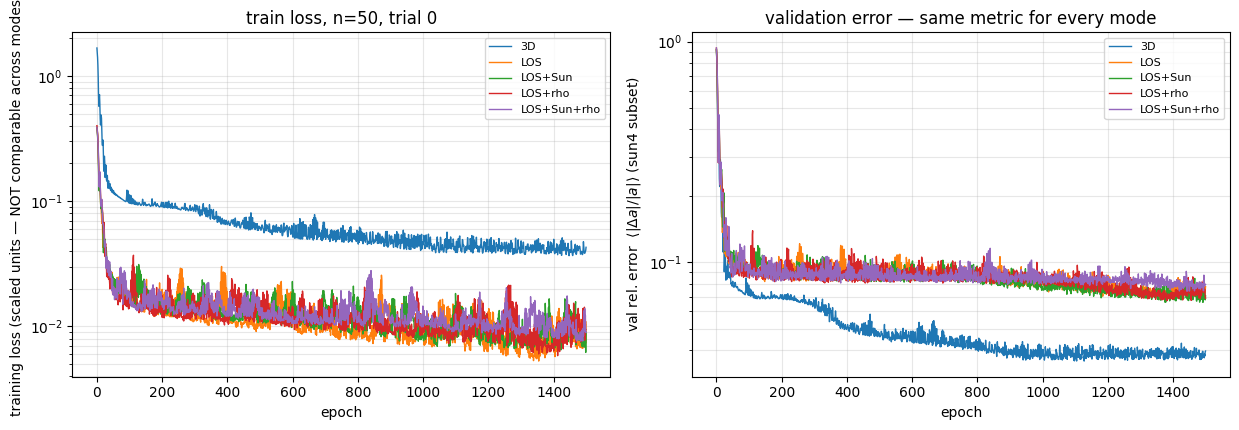

In [46]:
# Learning curves at n=50, trial 0 — tracking trainer (same losses as above,
# re-declared locally so the scan can also emit per-epoch metrics).
N_LC, VAL_SUB = 50, 512
x_val_lc = val_scaled['sun4'][0][:VAL_SUB]
a_val_lc = val_scaled['sun4'][1][:VAL_SUB]

rng = np.random.default_rng(0)                      # trial-0 subset, as in the sweep
sel = rng.choice(x_pool.shape[0], size=N_LC, replace=False)
x_lc, a_lc = x_pool[sel], a_pool[sel]
dx_lc = x_pool_phys[sel] - fd.OBSERVER
nv_lc = jnp.asarray(dx_lc / np.linalg.norm(dx_lc, axis=1, keepdims=True))


def data_terms_lc(m, x, a, nv, w):
    w3d, wlos, anch_on, lam_anchor, _ = w
    a_pred = m(x)['acceleration']
    dn = jnp.linalg.norm(a_pred - a, axis=1)
    tn = jnp.linalg.norm(a, axis=1)
    loss3d = jnp.mean(dn + LAMBDA_REL * dn / (tn + EPS))
    r = jnp.sum(a_pred * nv, axis=1) - jnp.sum(a * nv, axis=1)
    anchor_abs = jnp.abs(m(x_obs)['acceleration'] - a_obs).reshape(-1)
    denom = x.shape[0] + anch_on * anchor_abs.size
    loss_los = (jnp.sum(jnp.abs(r))
                + anch_on * lam_anchor * jnp.sum(anchor_abs)) / denom
    return w3d * loss3d + wlos * loss_los


def loss_norho_lc(params, x, a, nv, w):
    return data_terms_lc(nnx.merge(graphdef, params, rest), x, a, nv, w)


def loss_rho_lc(params, x, a, nv, colloc, w):
    m = nnx.merge(graphdef, params, rest)
    lap = m.compute_laplacian(colloc)
    return data_terms_lc(m, x, a, nv, w) + w[4] * jnp.mean(jax.nn.relu(-lap))


def val_relerr(p, xv, av):
    ap = nnx.merge(graphdef, p, rest)(xv)['acceleration']
    return jnp.mean(jnp.linalg.norm(ap - av, axis=1)
                    / jnp.linalg.norm(av, axis=1))


def make_tracking_trainer(loss_fn):
    @jax.jit
    def train_track(params, opt, xv, av, *arrays):
        def stepf(carry, _):
            p, o = carry
            losses, grads = jax.vmap(jax.value_and_grad(loss_fn))(p, *arrays)
            updates, o = tx.update(grads, o, p)
            p = optax.apply_updates(p, updates)
            rel = jax.vmap(val_relerr, in_axes=(0, None, None))(p, xv, av)
            return (p, o), (losses, rel)
        (p, _), hist = jax.lax.scan(stepf, (params, opt), None, length=EPOCHS)
        return p, hist
    return train_track


curves = {}
for modes_lc, loss_fn, needs_rho in ((NORHO_MODES, loss_norho_lc, False),
                                     (RHO_MODES, loss_rho_lc, True)):
    k = len(modes_lc)
    W = jnp.asarray([mode_weight_row(mo, 1.0, 1.0) for mo in modes_lc],
                    dtype=jnp.float32)
    X = jnp.stack([x_lc] * k)
    A = jnp.stack([a_lc] * k)
    NV = jnp.stack([nv_lc] * k)
    arrays = (X, A, NV, W) if not needs_rho else (
        X, A, NV, jnp.stack([colloc_by_trial[0]] * k), W)
    params = stack_states([params_by_trial[0]] * k)
    t0 = time.time()
    _, (hist_loss, hist_rel) = make_tracking_trainer(loss_fn)(
        params, tx.init(params), x_val_lc, a_val_lc, *arrays)
    jax.block_until_ready(hist_loss)
    print(f"tracked {k} models [{'+'.join(modes_lc)}] in {time.time()-t0:.1f}s")
    for i, mo in enumerate(modes_lc):
        curves[mo] = (np.asarray(hist_loss[:, i]), np.asarray(hist_rel[:, i]))

print('\nfinal epoch (train loss | val rel_err on the sun4 subset):')
for mo in MODES:
    tl, vr = curves[mo]
    print(f'  {mo:12s} {tl[-1]:.4f} | {vr[-1]:.4f}   '
          f'(val min {vr.min():.4f} at epoch {vr.argmin()})')

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
colors_lc = dict(zip(MODES, [f'C{i}' for i in range(5)]))
for mo in MODES:
    tl, vr = curves[mo]
    axes[0].plot(tl, color=colors_lc[mo], lw=1, label=mo)
    axes[1].plot(vr, color=colors_lc[mo], lw=1, label=mo)
axes[0].set_ylabel('training loss (scaled units — NOT comparable across modes)')
axes[0].set_title(f'train loss, n={N_LC}, trial 0')
axes[1].set_ylabel(r'val rel. error  $\langle|\Delta a|/|a|\rangle$ (sun4 subset)')
axes[1].set_title('validation error — same metric for every mode')
for ax in axes:
    ax.set_yscale('log'); ax.set_xlabel('epoch')
    ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=8)
fig.tight_layout()

## Appendix — the rotation curve: truth vs the recovered model

A rotation curve is just the radial force repackaged: $v_c(R)=\sqrt{R\,a_R}$
(circular-orbit centripetal balance). Both curves below are computed
identically — same gc15 evaluation points, same |z| < 1 kpc midplane cut,
same 1 kpc bins, medians over azimuth — the only difference is *whose*
acceleration goes in:

- **truth**: the direct-summation field (what notebook 01 rebuilt);
- **model**: the checkpointed `LOS+Sun+rho` ensembles (the realistic
  pulsar mode), one curve per trial → band = ensemble range.

Reading it: inside the training bubble the pulsar-mode curve tracks the
truth at the few-percent level (v_c error ≈ half the acceleration error,
thanks to the square root); outside the bubble it's pure extrapolation and
drifts to ~10–20% — the same story as the recovery-vs-n plots, but in the
units every galactic-dynamics audience knows. This is the miniature of the
"~50 pulsars vs 50k stars" comparison: an *acceleration-derived* rotation
curve assumes no equilibrium, so comparing it against a kinematic
(Jeans-derived) curve tests the equilibrium assumptions themselves.

n=50: median |Δv_c|/v_c in-bubble 1.1%, outside 12.3%
n=1000: median |Δv_c|/v_c in-bubble 4.5%, outside 16.6%


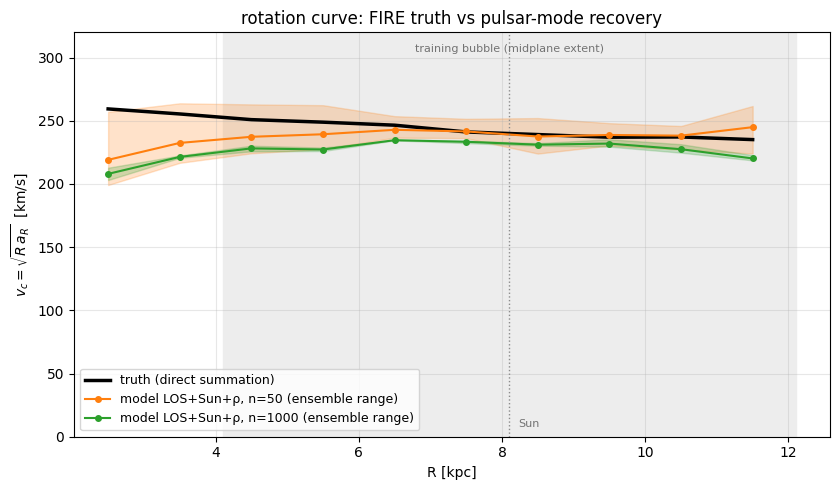

In [47]:
# Rotation curve: truth (direct summation) vs the LOS+Sun+rho ensembles.
KPCMYR_TO_KMS = 977.79222
R_SUN = float(np.linalg.norm(fd.OBSERVER))
a_tf = cfg['a_transformer']

x_val_g = val_scaled['gc15'][0]
xv_g = val_geom['gc15'][0]
a_true_g = np.asarray(a_tf.inverse_transform(val_scaled['gc15'][1]))

Rg = np.hypot(xv_g[:, 0], xv_g[:, 1])
thin = np.abs(xv_g[:, 2]) < 1.0
R_EDGES = np.arange(2.0, 14.01, 1.0)
bins = [(lo, hi) for lo, hi in zip(R_EDGES[:-1], R_EDGES[1:])
        if (thin & (Rg >= lo) & (Rg < hi)).sum() > 15]
mids = np.array([0.5 * (lo + hi) for lo, hi in bins])


def vc_of(a_phys):
    """Binned-median circular velocity [km/s] from a physical accel field."""
    aR = -(a_phys[:, 0] * xv_g[:, 0] + a_phys[:, 1] * xv_g[:, 1]) \
        / np.maximum(Rg, 1e-12)
    vc = np.sqrt(np.maximum(Rg * aR, 0.0)) * KPCMYR_TO_KMS
    return np.array([np.median(vc[thin & (Rg >= lo) & (Rg < hi)])
                     for lo, hi in bins])


def model_vc_band(n, mode):
    """Mean and min/max over the trial ensemble for one (n, mode)."""
    curves = []
    for g in trained_groups[n]:
        stacked = jax.tree.map(jnp.asarray, g['state'])
        for (trial, mo), i in g['members']:
            if mo != mode:
                continue
            m = nnx.merge(graphdef, take_member(stacked, i), rest)
            ap = np.asarray(a_tf.inverse_transform(m(x_val_g)['acceleration']))
            curves.append(vc_of(ap))
    c = np.stack(curves)
    return c.mean(axis=0), c.min(axis=0), c.max(axis=0)


vc_truth = vc_of(a_true_g)

fig, ax = plt.subplots(figsize=(8.5, 5))
trans = ax.get_xaxis_transform()          # x in data, y in axes fraction
ax.axvspan(R_SUN - 4.0, R_SUN + 4.0, color='0.93', zorder=0)
ax.text(R_SUN, 0.97, 'training bubble (midplane extent)', ha='center',
        va='top', transform=trans, fontsize=8, color='0.45')
ax.plot(mids, vc_truth, 'k-', lw=2.5, label='truth (direct summation)')
for n, color in [(50, 'C1'), (1000, 'C2')]:
    mean, lo, hi = model_vc_band(n, 'LOS+Sun+rho')
    ax.plot(mids, mean, 'o-', ms=4, color=color, lw=1.5,
            label=f'model LOS+Sun+ρ, n={n} (ensemble range)')
    ax.fill_between(mids, lo, hi, color=color, alpha=0.22)
ax.axvline(R_SUN, color='0.55', ls=':', lw=1)
ax.text(R_SUN + 0.12, 0.02, 'Sun', transform=trans, fontsize=8,
        color='0.45', va='bottom')
ax.set_xlabel('R [kpc]')
ax.set_ylabel(r'$v_c = \sqrt{R\,a_R}$  [km/s]')
ax.set_title('rotation curve: FIRE truth vs pulsar-mode recovery')
ax.set_ylim(0, 320)
ax.legend(fontsize=9, loc='lower left')
ax.grid(alpha=0.3)
fig.tight_layout()

for n in (50, 1000):
    mean, _, _ = model_vc_band(n, 'LOS+Sun+rho')
    inb = (mids > R_SUN - 4) & (mids < R_SUN + 4)
    err = np.abs(mean - vc_truth) / vc_truth
    print(f'n={n}: median |Δv_c|/v_c in-bubble {100*np.median(err[inb]):.1f}%, '
          f'outside {100*np.median(err[~inb]):.1f}%')